In [307]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import re
from collections import Counter
from nltk.corpus import stopwords, names
import nltk
nltk.download('stopwords')
nltk.download('names')

df = pd.read_csv("/content/test.csv")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Package names is already up-to-date!


In [302]:
# person_rows = df[df['transactor_type'] == 'Candidate']
person_rows = df[df['label'] == 1]

person_tokens = person_rows['full_name'].dropna().apply(lambda x: re.findall(r'\b\w+\b', x.lower()))
flat_person_names = [name for sublist in person_tokens for name in sublist]

stop_words = set(stopwords.words('english'))
unwanted_titles = {'mr', 'mrs', 'ms', 'dr', 'jr', 'sr', 'miss', 'rev'}
name_list = set(name.lower() for name in names.words())

cleaned_person_names = [
    name for name in flat_person_names
    if name not in stop_words
    and name not in unwanted_titles
    and len(name) > 1
    and name in name_list
]


top_names = [name for name, count in Counter(cleaned_person_names).most_common(10)]
print("Top 10 individual names:", top_names)

Top 10 individual names: ['john', 'michael', 'robert', 'david', 'james', 'richard', 'thomas', 'william', 'mary', 'mark']


In [303]:
org_rows = df[df['label'] == 0]

org_tokens = org_rows['full_name'].dropna().apply(lambda x: re.findall(r'\b\w+\b', x.lower()))
flat_org_words = [word for sublist in org_tokens for word in sublist]

cleaned_org_words = [
    word for word in flat_org_words
    if word not in stop_words
    and word not in unwanted_titles
    and word not in top_names
    and len(word) > 1
]

top_org_words = [word for word, count in Counter(cleaned_org_words).most_common(10)]
print("Top 10 org-related words:", top_org_words)

Top 10 org-related words: ['committee', 'elect', 'pac', 'inc', 'friends', 'arizona', 'campaign', 'state', 'llc', 'senate']


In [304]:
def is_pac(full_name, pac_words):
    if not isinstance(full_name, str):
        return 0
    name_list = re.findall(r'\b\w+\b', full_name.lower())
    return int(any(name in pac_words for name in name_list))

def is_org(full_name, org_words):
    if not isinstance(full_name, str):
        return 0
    name_list = re.findall(r'\b\w+\b', full_name.lower())
    return int(any(word in org_words for word in name_list))

df['is_pac_name'] = df['full_name'].apply(lambda x: is_pac(x, top_names))
df['is_org_name'] = df['full_name'].apply(lambda x: is_org(x, top_org_words))

In [297]:
#indices_to_drop = df1[df1['transactor_type'].notna()].index
#df1 = df1.drop(indices_to_drop)
#df1['transactor_type'].value_counts(dropna = False)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.25, random_state = 1)

In [298]:
rfc = RandomForestClassifier(random_state = 1)
rfc.fit(X_train, y_train)
predicted = rfc.predict(X_val)

In [306]:
accuracy = accuracy_score(y_val, predicted) * 100

recall = recall_score(y_val, predicted) * 100

precision = precision_score(y_val, predicted) * 100

f1= f1_score(y_val, predicted) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)
print()
print(classification_report(y_val, predicted))

Accuracy: 91.23222748815166
Recall: 92.03836930455635
Precision: 97.16455696202532
f1_score: 94.5320197044335

              precision    recall  f1-score   support

           0       0.70      0.87      0.78       447
           1       0.97      0.92      0.95      2085

    accuracy                           0.91      2532
   macro avg       0.84      0.90      0.86      2532
weighted avg       0.92      0.91      0.92      2532



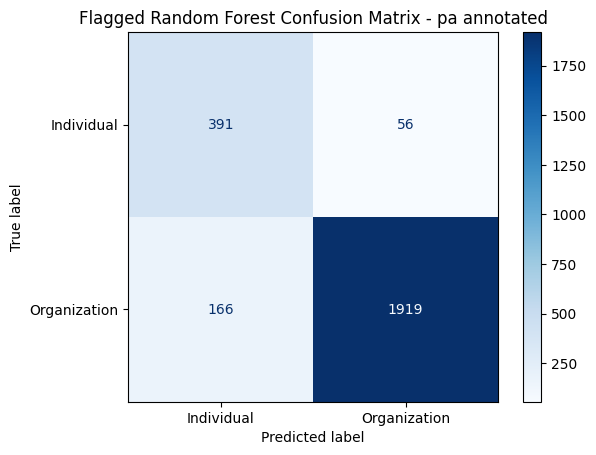

In [300]:
cm = confusion_matrix(y_val, predicted, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Flagged Random Forest Confusion Matrix - pa annotated")
# plt.savefig('Flagged Random Forest Confusion Matrix - pa annotated.png', transparent=True, bbox_inches = 'tight')
plt.show()